### Predicting solar irradiance  using Random Forest Regression
This notebook uses Random Forest to predict irradiance using radiant line measurements from solar panel sensors.
Data used to train model is no longer available hence the code cannot be run

In [1]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from datetime import timedelta
import calendar
from datetime import datetime
from numpy import asarray
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot
from pathlib import Path
from glob import glob

In [90]:
#Read irradiance data
files = list(glob(r"data\cms\*.csv"))
irr_dfs = []
for f in files:
    temp = pd.read_csv(f)
    irr_dfs.append(temp)
    
irradiance = pd.concat(irr_dfs, ignore_index=True)
irradiance.head()

,collectTime,devId,temperature,pv_temperature,wind_speed,wind_direction,radiant_total,radiant_line,horiz_radiant_line,horiz_radiant_total
0,1577808000000,-118839675197220,27.5,27.7,NaN,NaN,0.0,0.0,NaN,NaN
1,1577808300000,-118839675197220,27.5,27.7,NaN,NaN,0.0,0.4,NaN,NaN
2,1577808600000,-118839675197220,27.4,27.6,NaN,NaN,0.0,0.5,NaN,NaN
3,1577808900000,-118839675197220,27.3,27.5,NaN,NaN,0.0,0.4,NaN,NaN
4,1577809200000,-118839675197220,27.3,27.5,NaN,NaN,0.0,0.4,NaN,NaN


In [91]:
#format time data
irradiance['datetime'] = irradiance['collectTime']/1000
irradiance['datetime'] = irradiance['datetime'].transform(lambda x: datetime.fromtimestamp(x))
irradiance = irradiance.sort_values('datetime')
irradiance

,collectTime,devId,temperature,pv_temperature,wind_speed,wind_direction,radiant_total,radiant_line,horiz_radiant_line,horiz_radiant_total,datetime
0,1577808000000,-118839675197220,27.5,27.7,NaN,NaN,0.000,0.0,NaN,NaN,2020-01-01 00:00:00
1,1577808300000,-118839675197220,27.5,27.7,NaN,NaN,0.000,0.4,NaN,NaN,2020-01-01 00:05:00
2,1577808600000,-118839675197220,27.4,27.6,NaN,NaN,0.000,0.5,NaN,NaN,2020-01-01 00:10:00
3,1577808900000,-118839675197220,27.3,27.5,NaN,NaN,0.000,0.4,NaN,NaN,2020-01-01 00:15:00
4,1577809200000,-118839675197220,27.3,27.5,NaN,NaN,0.000,0.4,NaN,NaN,2020-01-01 00:20:00
...,...,...,...,...,...,...,...,...,...,...,...
8629,1580484900000,-118839675197220,27.7,27.4,NaN,NaN,23.882,0.5,NaN,NaN,2020-01-31 23:35:00
8630,1580485200000,-118839675197220,27.7,27.4,NaN,NaN,23.883,0.5,NaN,NaN,2020-01-31 23:40:00
8631,1580485500000,-118839675197220,27.6,27.4,NaN,NaN,23.883,0.5,NaN,NaN,2020-01-31 23:45:00
8632,1580485800000,-118839675197220,27.6,27.3,NaN,NaN,23.883,0.5,NaN,NaN,2020-01-31 23:50:00


In [92]:
df = irradiance[['datetime','radiant_line']]
df = df.set_index('datetime')
#df = df.between_time('06:45','19:15')
df

,radiant_line
datetime,
2020-01-01 00:00:00,0.0
2020-01-01 00:05:00,0.4
2020-01-01 00:10:00,0.5
2020-01-01 00:15:00,0.4
2020-01-01 00:20:00,0.4
...,...
2020-01-31 23:35:00,0.5
2020-01-31 23:40:00,0.5
2020-01-31 23:45:00,0.5


In [93]:
# transform a time series dataset into a supervised learning dataset
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols = list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    # put it all together
    agg = pd.concat(cols, axis=1)
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg.values

In [94]:
data = series_to_supervised(df, n_in=1, n_out=1, dropnan=True)

In [95]:
# split a univariate dataset (radiant_line) into train/test sets
def train_test_split(data, n_test):
    return data[:-n_test, :], data[-n_test:, :]

In [96]:
# fit an random forest model and make a one step prediction
def random_forest_forecast(train, testX):
    # transform list into array
    train = np.asarray(train)
    # split into input and output columns
    trainX, trainy = train[:, :-1], train[:, -1]
    # fit model
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    # make a one-step prediction
    yhat = model.predict([testX])
    return yhat[0]

In [97]:
# walk-forward validation for univariate data
def walk_forward_validation(data, n_test):
    predictions = list()
    # split dataset
    train, test = train_test_split(data, n_test)
    history = list(train)
    # step over each time-step in the test set
    for i in range(len(test)):
        # split test row into input and output columns
        testX, testy = test[i, :-1], test[i, -1]
        # fit model on history and make a prediction
        yhat = random_forest_forecast(history, testX)
        # store forecast in list of predictions
        predictions.append(yhat)
        # add actual observation to history for the next loop
        history.append(test[i])
        # summarize progress
        print('>expected=%.1f, predicted=%.1f' % (testy, yhat))
    # estimate prediction error
    error = mean_absolute_error(test[:, -1], predictions)
    return error, test[:, 1], predictions

In [98]:
#night time
mae, y, yhat = walk_forward_validation(data, 6)

>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4


In [99]:
print('MAE: %.3f' % mae)

MAE: 0.068


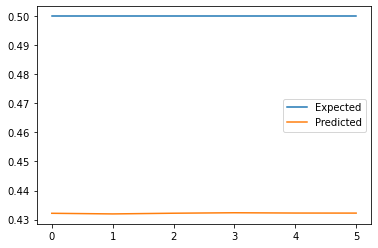

In [100]:
# plot expected vs predicted
pyplot.plot(y, label='Expected')
pyplot.plot(yhat, label='Predicted')
pyplot.legend()
pyplot.show()

In [101]:
sumvalue=np.sum(y)
mape=np.sum(np.abs((y - yhat)))/sumvalue*100

In [102]:
mape

13.5636741708101

In [109]:
mae, y, yhat = walk_forward_validation(data, 288)

>expected=0.5, predicted=0.4
>expected=0.6, predicted=0.4
>expected=0.4, predicted=0.5
>expected=0.4, predicted=0.8
>expected=0.5, predicted=0.8
>expected=0.2, predicted=0.4
>expected=0.6, predicted=0.4
>expected=0.5, predicted=0.5
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.1, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.4, predicted=0.4
>expected=0.4, predicted=0.8
>expected=0.4, predicted=0.8
>expected=0.2, predicted=0.8
>expected=0.4, predicted=0.4
>expected=0.5, predicted=0.7
>expected=0.5, predicted=0.4
>expected=0.4, predicted=0.4
>expected=0.4, predicted=0.7
>expected=0.4, predicted=0.8
>expected=0.5, predicted=0.8
>expected=0.6, predicted=0.4
>expected=0.5, predicted=0.5
>expected=0.5, predicted=0.4
>expected=0.4, predicted=0.4
>expected=0.2, predicted=0.8
>expected=0.4, predicted=0.4
>expected=0.4, predicted=0.7
>expected=0.4,

>expected=0.5, predicted=0.4
>expected=0.4, predicted=0.4
>expected=0.5, predicted=0.8
>expected=0.2, predicted=0.4
>expected=0.0, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.4, predicted=0.4
>expected=0.2, predicted=0.8
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.4, predicted=0.4
>expected=0.5, predicted=0.8
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4
>expected=0.5, predicted=0.4


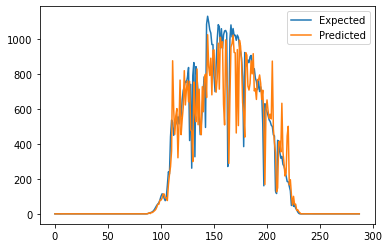

In [111]:
# plot expected vs predicted over time - 31 jan
pyplot.plot(y, label='Expected')
pyplot.plot(yhat, label='Predicted')
pyplot.legend()
pyplot.show()

In [113]:
sumvalue=np.sum(y)
mape=np.sum(np.abs((y - yhat)))/sumvalue*100
mape

22.120414321225283